# Integración de señales y caracterización de patrones

In [1]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

In [2]:
# Parametros

MIN_AWARD_AMOUNT_CONCENTRATION = 5_000
MIN_BUYER_AWARDS_CONCENTRATION = 5

RECURRENCE_WINDOW_DAYS = 90
RECURRENCE_MIN_PROCEDURES = 4  # equivalente a >3

# Percentiles exploratorios para identificar valores estructuralmente altos.
# No representan "riesgo" ni una clasificación normativa.
SCREENING_PERCENTILE = 0.90

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [3]:
# Carga de bases procesadas

DATA_PROCESSED = Path("../data/processed")
NEO4J_DIR = DATA_PROCESSED / "neo4j"
ANALYTICS_DIR = DATA_PROCESSED / "analytics"
ANALYTICS_DIR.mkdir(parents=True, exist_ok=True)

procedimientos_path = DATA_PROCESSED / "01_procedimientos_limpios_2025.csv"
participacion_path = DATA_PROCESSED / "02_participacion_oferentes_limpia_2025.csv"
adjudicaciones_path = DATA_PROCESSED / "03_adjudicaciones_limpias_2025.csv"
network_metrics_path = NEO4J_DIR / "actor_network_metrics_2025.csv"

for p in [
    procedimientos_path,
    participacion_path,
    adjudicaciones_path,
    network_metrics_path,
]:
    if not p.exists():
        raise FileNotFoundError(f"No se encontró el archivo requerido: {p.resolve()}")

dtype_common = {
    "ocid": "string",
    "buyer_id": "string",
    "supplier_id": "string",
    "tenderer_id": "string",
    "cpc_5": "string",
}

procedimientos_df = pd.read_csv(
    procedimientos_path,
    dtype={k: v for k, v in dtype_common.items() if k in ["ocid", "buyer_id"]},
)

participacion_df = pd.read_csv(
    participacion_path,
    dtype={k: v for k, v in dtype_common.items() if k in ["ocid", "tenderer_id"]},
)

adjudicaciones_df = pd.read_csv(
    adjudicaciones_path,
    dtype={
        "ocid": "string",
        "buyer_id": "string",
        "supplier_id": "string",
        "cpc_5": "string",
    },
)

network_metrics_df = pd.read_csv(
    network_metrics_path,
    dtype={"actor_id": "string"},
)

print("Procedimientos:", len(procedimientos_df))
print("Participaciones de oferentes:", len(participacion_df))
print("Adjudicaciones:", len(adjudicaciones_df))
print("Actores con métricas de red:", len(network_metrics_df))


Procedimientos: 18326
Participaciones de oferentes: 79425
Adjudicaciones: 15718
Actores con métricas de red: 7706


In [4]:
# Validaciones minimas de entrada

required_proc = {"ocid", "buyer_id", "number_of_tenderers"}
required_award = {
    "ocid",
    "buyer_id",
    "supplier_id",
    "award_amount",
    "award_date_local",
    "cpc_5",
}
required_network = {
    "actor_type",
    "actor_id",
    "degree",
    "strength_frequency",
    "strength_amount",
}

def assert_columns(df, required, df_name):
    missing = required - set(df.columns)
    if missing:
        raise ValueError(
            f"{df_name} no contiene las columnas requeridas: {sorted(missing)}"
        )

assert_columns(procedimientos_df, required_proc, "procedimientos_df")
assert_columns(adjudicaciones_df, required_award, "adjudicaciones_df")
assert_columns(network_metrics_df, required_network, "network_metrics_df")

if procedimientos_df["ocid"].duplicated().any():
    raise ValueError("La base de procedimientos contiene OCID duplicados.")

if adjudicaciones_df[["ocid", "supplier_id"]].isna().any().any():
    raise ValueError("Existen adjudicaciones sin OCID o supplier_id.")

print("Validaciones mínimas superadas.")


Validaciones mínimas superadas.


In [5]:
# Preparacion de variables base

adjudicaciones_df["award_amount"] = pd.to_numeric(
    adjudicaciones_df["award_amount"],
    errors="coerce",
)

adjudicaciones_df["award_date_dt"] = pd.to_datetime(
    adjudicaciones_df["award_date_local"],
    errors="coerce",
)

procedimientos_df["number_of_tenderers"] = pd.to_numeric(
    procedimientos_df["number_of_tenderers"],
    errors="coerce",
)

# Columnas descriptivas preferidas.
buyer_name_col = (
    "buyer_name_normalized"
    if "buyer_name_normalized" in procedimientos_df.columns
    else "buyer_name"
)

supplier_name_col = (
    "nombre_proveedor_limpio"
    if "nombre_proveedor_limpio" in adjudicaciones_df.columns
    else "supplier_name"
)

print("Buyer name:", buyer_name_col)
print("Supplier name:", supplier_name_col)


Buyer name: buyer_name_normalized
Supplier name: nombre_proveedor_limpio


In [6]:
# Concentracion por entidad contratante
# - Concentracion monetaria
# - Concentracion por frecuencia

def normalized_hhi(hhi, n):
    if pd.isna(hhi) or pd.isna(n) or n <= 1:
        return np.nan
    return (hhi - (1 / n)) / (1 - (1 / n))


def normalized_entropy(shares):
    shares = np.asarray(shares, dtype=float)
    shares = shares[shares > 0]

    n = len(shares)
    if n <= 1:
        return np.nan

    entropy = -(shares * np.log(shares)).sum()
    return entropy / np.log(n)


def concentration_by_buyer(
    awards,
    min_amount=5_000,
    min_buyer_awards=5,
):
    df = awards.loc[
        awards["award_amount"].notna()
        & (awards["award_amount"] >= min_amount)
    ].copy()

    # Número de adjudicaciones por buyer en el universo filtrado.
    buyer_counts = (
        df.groupby("buyer_id")["ocid"]
        .nunique()
        .rename("numero_adjudicaciones")
    )

    eligible_buyers = buyer_counts[
        buyer_counts >= min_buyer_awards
    ].index

    df = df[df["buyer_id"].isin(eligible_buyers)].copy()

    pair = (
        df.groupby(["buyer_id", "supplier_id"], as_index=False)
        .agg(
            frequency=("ocid", "nunique"),
            amount=("award_amount", "sum"),
        )
    )

    rows = []

    for buyer_id, g in pair.groupby("buyer_id"):
        n_suppliers = g["supplier_id"].nunique()
        total_freq = g["frequency"].sum()
        total_amount = g["amount"].sum()

        freq_shares = g["frequency"] / total_freq
        amount_shares = g["amount"] / total_amount

        hhi_freq = float((freq_shares ** 2).sum())
        hhi_amount = float((amount_shares ** 2).sum())

        cr4_amount = float(
            g.nlargest(4, "amount")["amount"].sum() / total_amount
        )

        rows.append({
            "buyer_id": buyer_id,
            "numero_adjudicaciones": int(total_freq),
            "numero_proveedores": int(n_suppliers),
            "monto_total": float(total_amount),
            "hhi_frecuencia": hhi_freq,
            "hhi_monetario": hhi_amount,
            "hhi_frecuencia_normalizado": normalized_hhi(
                hhi_freq, n_suppliers
            ),
            "hhi_monetario_normalizado": normalized_hhi(
                hhi_amount, n_suppliers
            ),
            "cr4_monetario": cr4_amount,
            "entropia_frecuencia_normalizada": normalized_entropy(
                freq_shares
            ),
            "entropia_monetaria_normalizada": normalized_entropy(
                amount_shares
            ),
        })

    return pd.DataFrame(rows), pair


concentration_df, buyer_supplier_concentration_df = concentration_by_buyer(
    adjudicaciones_df,
    min_amount=MIN_AWARD_AMOUNT_CONCENTRATION,
    min_buyer_awards=MIN_BUYER_AWARDS_CONCENTRATION,
)

print("Entidades en análisis de concentración:", len(concentration_df))
display(concentration_df.head())


Entidades en análisis de concentración: 687


,buyer_id,numero_adjudicaciones,numero_proveedores,monto_total,hhi_frecuencia,hhi_monetario,hhi_frecuencia_normalizado,hhi_monetario_normalizado,cr4_monetario,entropia_frecuencia_normalizada,entropia_monetaria_normalizada
0,EC-RUC-0160000190001-30745,58,52,"11,455,801.620000",0.021998,0.095605,0.002821,0.077871,0.514576,0.986775,0.743893
1,EC-RUC-0160000270001-2616,62,56,"8,189,359.470000",0.019251,0.093532,0.001419,0.077051,0.551640,0.991957,0.715556
2,EC-RUC-0160000350001-89973,13,10,"424,391.470000",0.124260,0.190571,0.026956,0.100634,0.776187,0.957526,0.828425
3,EC-RUC-0160000430001-12403,9,9,"1,544,204.030000",0.111111,0.543395,0.000000,0.486319,0.944511,1.000000,0.474622
4,EC-RUC-0160000510001-8098,20,17,"747,559.480000",0.065000,0.098830,0.006563,0.042506,0.532402,0.983967,0.885452


In [7]:
concentration_summary = concentration_df[
    [
        "hhi_frecuencia_normalizado",
        "hhi_monetario_normalizado",
        "cr4_monetario",
        "entropia_monetaria_normalizada",
    ]
].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T

display(concentration_summary)


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
hhi_frecuencia_normalizado,687.000000,0.010070,0.020279,-0.000000,0.000000,0.003801,0.011291,0.027778,0.040000,0.111111,0.250000
hhi_monetario_normalizado,687.000000,0.130272,0.132337,0.006432,0.046818,0.085636,0.163725,0.285063,0.377170,0.672921,0.894554
cr4_monetario,687.000000,0.727061,0.193691,0.178753,0.589675,0.762890,0.885713,0.957242,0.985197,1.000000,1.000000
entropia_monetaria_normalizada,687.000000,0.807191,0.127981,0.145600,0.752244,0.833583,0.896122,0.935799,0.953674,0.978483,0.991229


In [8]:
# Recurrencia temporal comprador-proveedor

def recurrence_windows(
    awards,
    window_days=90,
    min_procedures=4,
):
    required = [
        "buyer_id",
        "supplier_id",
        "cpc_5",
        "ocid",
        "award_date_dt",
    ]

    df = awards[required].dropna().copy()

    # Una fila por procedimiento dentro de cada combinación.
    df = (
        df.sort_values("award_date_dt")
        .drop_duplicates(
            ["buyer_id", "supplier_id", "cpc_5", "ocid"],
            keep="first",
        )
    )

    rows = []

    for (buyer_id, supplier_id, cpc_5), g in df.groupby(
        ["buyer_id", "supplier_id", "cpc_5"],
        sort=False,
    ):
        g = g.sort_values("award_date_dt").reset_index(drop=True)

        dates = g["award_date_dt"]
        ocids = g["ocid"]

        max_count = 0
        best_start = None
        best_end = None
        best_ocids = None

        left = 0

        for right in range(len(g)):
            while (
                dates.iloc[right] - dates.iloc[left]
            ).days > window_days:
                left += 1

            window_count = right - left + 1

            if window_count > max_count:
                max_count = window_count
                best_start = dates.iloc[left]
                best_end = dates.iloc[right]
                best_ocids = list(ocids.iloc[left:right + 1])

        rows.append({
            "buyer_id": buyer_id,
            "supplier_id": supplier_id,
            "cpc_5": cpc_5,
            "max_procesos_ventana": int(max_count),
            "recurrencia": int(max_count >= min_procedures),
            "ventana_inicio": best_start,
            "ventana_fin": best_end,
            "ocids_ventana": "|".join(best_ocids or []),
        })

    return pd.DataFrame(rows)


recurrence_df = recurrence_windows(
    adjudicaciones_df,
    window_days=RECURRENCE_WINDOW_DAYS,
    min_procedures=RECURRENCE_MIN_PROCEDURES,
)

print("Combinaciones Buyer-Supplier-CPC5:", len(recurrence_df))
print("Combinaciones recurrentes:", int(recurrence_df["recurrencia"].sum()))

display(
    recurrence_df[
        recurrence_df["recurrencia"] == 1
    ].sort_values(
        "max_procesos_ventana",
        ascending=False
    ).head(20)
)


Combinaciones Buyer-Supplier-CPC5: 14400
Combinaciones recurrentes: 23


,buyer_id,supplier_id,cpc_5,max_procesos_ventana,recurrencia,ventana_inicio,ventana_fin,ocids_ventana
971,EC-RUC-1768012710001-43246,EC-RUC-1791222032001-4906,35290,5,1,2025-04-08 19:07:18,2025-05-21 09:41:16,ocds-5wno2w-SIE-HE-1-2025-011-43246|ocds-5wno2...
4433,EC-RUC-0360000230001-2422,EC-RUC-0190370348001-321986,62221,5,1,2025-06-13 11:36:39,2025-08-28 14:28:06,ocds-5wno2w-SIE-GADMAZ-2025-015-2422|ocds-5wno...
10386,EC-RUC-0968560160001-2810,EC-RUC-1790691810001-4033,35290,5,1,2025-11-07 17:04:00,2025-12-31 14:53:50,ocds-5wno2w-SIE-HTMC-2025-053-2810|ocds-5wno2w...
9792,EC-RUC-1760003680001-2472,EC-RUC-1702827146001-20996,37370,5,1,2025-10-17 17:02:32,2025-11-21 11:53:52,ocds-5wno2w-SIE-GADIPMC-2025-46-2472|ocds-5wno...
5640,EC-RUC-0968503870001-17993,EC-RUC-0992187905001-6835,35290,5,1,2025-07-04 20:05:49,2025-08-18 17:26:30,ocds-5wno2w-SIE-HAGP-2025-038-17993|ocds-5wno2...
3938,EC-RUC-1768189800001-868544,EC-RUC-0991410465001-11294,35260,5,1,2025-06-05 14:28:32,2025-08-06 17:09:17,ocds-5wno2w-SIE-HGSQ-2025-056-868544|ocds-5wno...
1333,EC-RUC-1768189800001-868544,EC-RUC-0190146677001-11735,35290,5,1,2025-04-16 16:37:21,2025-05-27 15:22:58,ocds-5wno2w-SIE-HGSQ-2025-005-868544|ocds-5wno...
2571,EC-RUC-1768181150001-594674,EC-RUC-1791931483001-10379,35290,4,1,2025-05-13 16:22:39,2025-06-16 14:22:56,ocds-5wno2w-SIE-HGDC-2025-007-594674|ocds-5wno...
1446,EC-RUC-0160017400001-87497,EC-RUC-1790642992001-3710,35290,4,1,2025-04-22 11:10:02,2025-05-29 16:37:22,ocds-5wno2w-SIE-HEJCA-2025-067-87497|ocds-5wno...
1153,EC-RUC-1560500670001-15857,EC-RUC-1791310233001-12349,35290,4,1,2025-04-14 11:57:12,2025-06-20 15:03:52,ocds-5wno2w-SIE-HGJMVI-2025-0008-15857|ocds-5w...


In [ ]:
# Participación de oferentes

procedure_participation_df = procedimientos_df[
    ["ocid", "buyer_id", "number_of_tenderers"]
].copy()

observed_participation = (
    procedure_participation_df["number_of_tenderers"].notna()
)

procedure_participation_df["low_participation_1"] = pd.Series(
    pd.NA,
    index=procedure_participation_df.index,
    dtype="Float64",
)

procedure_participation_df.loc[
    observed_participation,
    "low_participation_1",
] = (
    procedure_participation_df.loc[
        observed_participation,
        "number_of_tenderers",
    ].eq(1).astype(float)
)

procedure_participation_df[
    "low_participation_3_or_less"
] = pd.Series(
    pd.NA,
    index=procedure_participation_df.index,
    dtype="Float64",
)

procedure_participation_df.loc[
    observed_participation,
    "low_participation_3_or_less",
] = (
    procedure_participation_df.loc[
        observed_participation,
        "number_of_tenderers",
    ].le(3).astype(float)
)

participation_summary = (
    procedure_participation_df["number_of_tenderers"]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

display(participation_summary.to_frame("number_of_tenderers"))

print(
    "Procedimientos con participación observada:",
    int(observed_participation.sum()),
    "/",
    len(procedure_participation_df),
)

,number_of_tenderers
count,"18,033.000000"
mean,4.404425
std,3.765014
min,1.000000
25%,2.000000
50%,3.000000
75%,6.000000
90%,9.000000
95%,12.000000
99%,18.000000


Procedimientos con participación observada: 18033 / 18326


In [10]:
# Participación asociada a cada relación Buyer-Supplier.

award_participation_df = adjudicaciones_df[
    [
        "ocid",
        "buyer_id",
        "supplier_id",
        "cpc_5",
        "award_amount",
        "award_date_dt",
    ]
].merge(
    procedure_participation_df,
    on=["ocid", "buyer_id"],
    how="left",
)

relation_participation_df = (
    award_participation_df
    .groupby(["buyer_id", "supplier_id"], as_index=False)
    .agg(
        relation_procedures=("ocid", "nunique"),
        relation_total_amount=("award_amount", "sum"),
        tenderers_mean=("number_of_tenderers", "mean"),
        tenderers_median=("number_of_tenderers", "median"),
        participation_observed_procedures=(
            "number_of_tenderers",
            "count",
        ),
        single_bidder_share=("low_participation_1", "mean"),
        low_participation_share=(
            "low_participation_3_or_less",
            "mean",
        ),
        missing_participation=(
            "number_of_tenderers",
            lambda s: int(s.isna().sum()),
        ),
    )
)

relation_participation_df[
    "participation_coverage"
] = (
    relation_participation_df[
        "participation_observed_procedures"
    ]
    / relation_participation_df["relation_procedures"]
)

display(relation_participation_df.head())

print(
    "Relaciones sin información de participación:",
    int(
        relation_participation_df[
            "participation_observed_procedures"
        ].eq(0).sum()
    ),
)

,buyer_id,supplier_id,relation_procedures,relation_total_amount,tenderers_mean,tenderers_median,participation_observed_procedures,single_bidder_share,low_participation_share,missing_participation,participation_coverage
0,EC-RUC-0160000190001-30745,EC-RUC-0101364107001-30471,2,"1,974,600.000000",4.000000,4.000000,2,0.500000,0.500000,0,1.000000
1,EC-RUC-0160000190001-30745,EC-RUC-0101697910001-17674,1,"747,000.000000",8.000000,8.000000,1,0.000000,0.000000,0,1.000000
2,EC-RUC-0160000190001-30745,EC-RUC-0102131158001-389116,1,"44,320.000000",7.000000,7.000000,1,0.000000,0.000000,0,1.000000
3,EC-RUC-0160000190001-30745,EC-RUC-0102141850001-752968,1,"67,999.000000",5.000000,5.000000,1,0.000000,0.000000,0,1.000000
4,EC-RUC-0160000190001-30745,EC-RUC-0102664760001-84882,1,"37,368.000000",2.000000,2.000000,1,0.000000,1.000000,0,1.000000


Relaciones sin información de participación: 2


In [11]:
# Preparación y validación de métricas de red

required_network_columns = {
    "actor_type",
    "actor_id",
    "degree",
    "strength_frequency",
    "strength_amount",
    "betweenness",
}

missing_network_columns = (
    required_network_columns - set(network_metrics_df.columns)
)

if missing_network_columns:
    raise ValueError(
        "actor_network_metrics_2025.csv no contiene las columnas "
        f"requeridas: {sorted(missing_network_columns)}. "
        "Regenera la exportación desde el Notebook 05."
    )

for col in [
    "degree",
    "strength_frequency",
    "strength_amount",
    "betweenness",
]:
    network_metrics_df[col] = pd.to_numeric(
        network_metrics_df[col],
        errors="coerce",
    )

betweenness_non_null = int(
    network_metrics_df["betweenness"].notna().sum()
)

print(
    "Actores con betweenness disponible:",
    betweenness_non_null,
    "/",
    len(network_metrics_df),
)

display(
    network_metrics_df[
        [
            "degree",
            "strength_frequency",
            "strength_amount",
            "betweenness",
        ]
    ].describe()
)

if betweenness_non_null == 0:
    raise ValueError(
        "La columna 'betweenness' existe, pero todos sus valores son nulos. "
        "El Notebook 06 no continuará silenciosamente sin esta métrica. "
        "Revisa el cálculo y la exportación desde el Notebook 05."
    )

buyer_network_df = (
    network_metrics_df[
        network_metrics_df["actor_type"].eq("Buyer")
    ]
    .rename(columns={
        "actor_id": "buyer_id",
        "actor_name": "buyer_name_network",
        "degree": "buyer_degree",
        "strength_frequency": "buyer_strength_frequency",
        "strength_amount": "buyer_strength_amount",
        "betweenness": "buyer_betweenness",
    })
)

supplier_network_df = (
    network_metrics_df[
        network_metrics_df["actor_type"].eq("Supplier")
    ]
    .rename(columns={
        "actor_id": "supplier_id",
        "actor_name": "supplier_name_network",
        "degree": "supplier_degree",
        "strength_frequency": "supplier_strength_frequency",
        "strength_amount": "supplier_strength_amount",
        "betweenness": "supplier_betweenness",
    })
)

buyer_network_keep = [
    c for c in [
        "buyer_id",
        "buyer_name_network",
        "buyer_degree",
        "buyer_strength_frequency",
        "buyer_strength_amount",
        "buyer_betweenness",
    ]
    if c in buyer_network_df.columns
]

supplier_network_keep = [
    c for c in [
        "supplier_id",
        "supplier_name_network",
        "supplier_degree",
        "supplier_strength_frequency",
        "supplier_strength_amount",
        "supplier_betweenness",
    ]
    if c in supplier_network_df.columns
]

buyer_network_df = buyer_network_df[
    buyer_network_keep
].copy()

supplier_network_df = supplier_network_df[
    supplier_network_keep
].copy()

print("Buyers con métricas:", len(buyer_network_df))
print("Suppliers con métricas:", len(supplier_network_df))

Actores con betweenness disponible: 7706 / 7706


,degree,strength_frequency,strength_amount,betweenness
count,"7,706.000000","7,706.000000","7,706.000000","7,706.000000"
mean,3.501947,4.079419,"390,644.143528","14,522.773294"
std,8.246561,10.940897,"1,702,388.482828","75,918.846850"
min,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,"27,736.367500",0.000000
50%,1.000000,1.000000,"71,541.180000",0.000000
75%,3.000000,3.000000,"240,457.820000","6,244.430697"
max,312.000000,457.000000,"54,271,908.420000","3,949,879.830161"


Buyers con métricas: 1737
Suppliers con métricas: 5969


In [12]:
# Base integrada Buyer-Supplier.

relation_base_df = (
    adjudicaciones_df
    .groupby(["buyer_id", "supplier_id"], as_index=False)
    .agg(
        relation_frequency=("ocid", "nunique"),
        relation_amount=("award_amount", "sum"),
        relation_first_award=("award_date_dt", "min"),
        relation_last_award=("award_date_dt", "max"),
        relation_cpc5_count=("cpc_5", "nunique"),
    )
)

# Número de procedimientos de la relación con fecha de adjudicación válida.
relation_dated_procedures_df = (
    adjudicaciones_df[
        adjudicaciones_df["award_date_dt"].notna()
    ]
    .groupby(
        ["buyer_id", "supplier_id"],
        as_index=False,
    )
    .agg(
        relation_procedures_with_date=("ocid", "nunique")
    )
)

relation_base_df = relation_base_df.merge(
    relation_dated_procedures_df,
    on=["buyer_id", "supplier_id"],
    how="left",
)

relation_base_df[
    "relation_procedures_with_date"
] = (
    relation_base_df["relation_procedures_with_date"]
    .fillna(0)
    .astype(int)
)

relation_base_df[
    "award_date_coverage"
] = (
    relation_base_df["relation_procedures_with_date"]
    / relation_base_df["relation_frequency"]
)

relation_recurrence_df = (
    recurrence_df
    .groupby(["buyer_id", "supplier_id"], as_index=False)
    .agg(
        recurrent_cpc5_count=("recurrencia", "sum"),
        max_procesos_90d=("max_procesos_ventana", "max"),
        recurrence_any=("recurrencia", "max"),
    )
)

relation_integrated_df = (
    relation_base_df
    .merge(
        relation_participation_df,
        on=["buyer_id", "supplier_id"],
        how="left",
    )
    .merge(
        relation_recurrence_df,
        on=["buyer_id", "supplier_id"],
        how="left",
    )
    .merge(
        concentration_df,
        on="buyer_id",
        how="left",
    )
    .merge(
        buyer_network_df,
        on="buyer_id",
        how="left",
    )
    .merge(
        supplier_network_df,
        on="supplier_id",
        how="left",
    )
)

relation_integrated_df["recurrence_any"] = (
    relation_integrated_df["recurrence_any"]
    .fillna(0)
    .astype(int)
)

relation_integrated_df["recurrent_cpc5_count"] = (
    relation_integrated_df["recurrent_cpc5_count"]
    .fillna(0)
    .astype(int)
)

# Disponibilidad de la dimensión de recurrencia:
# - Si una relación tiene menos de 4 procedimientos, sabemos que no puede
#   cumplir la regla principal, incluso si alguna fecha falta.
# - Si tiene 4 o más, exigimos cobertura completa de fechas para interpretar
#   ausencia de recurrencia con seguridad.
relation_integrated_df[
    "recurrence_available"
] = (
    relation_integrated_df["relation_frequency"].lt(
        RECURRENCE_MIN_PROCEDURES
    )
    | relation_integrated_df["award_date_coverage"].eq(1.0)
)

print("Relaciones integradas:", len(relation_integrated_df))
print(
    "Relaciones con recurrencia evaluable:",
    int(relation_integrated_df["recurrence_available"].sum()),
    "/",
    len(relation_integrated_df),
)
display(relation_integrated_df.head())

Relaciones integradas: 13493
Relaciones con recurrencia evaluable: 13493 / 13493


,buyer_id,supplier_id,relation_frequency,relation_amount,relation_first_award,relation_last_award,relation_cpc5_count,relation_procedures_with_date,award_date_coverage,relation_procedures,relation_total_amount,tenderers_mean,tenderers_median,participation_observed_procedures,single_bidder_share,low_participation_share,missing_participation,participation_coverage,recurrent_cpc5_count,max_procesos_90d,recurrence_any,numero_adjudicaciones,numero_proveedores,monto_total,hhi_frecuencia,hhi_monetario,hhi_frecuencia_normalizado,hhi_monetario_normalizado,cr4_monetario,entropia_frecuencia_normalizada,entropia_monetaria_normalizada,buyer_name_network,buyer_degree,buyer_strength_frequency,buyer_strength_amount,buyer_betweenness,supplier_name_network,supplier_degree,supplier_strength_frequency,supplier_strength_amount,supplier_betweenness,recurrence_available
0,EC-RUC-0160000190001-30745,EC-RUC-0101364107001-30471,2,"1,974,600.000000",2025-04-25 11:44:41,2025-09-04 15:48:16,1,2,1.000000,2,"1,974,600.000000",4.000000,4.000000,2,0.500000,0.500000,0,1.000000,0,1,0,58.000000,52.000000,"11,455,801.620000",0.021998,0.095605,0.002821,0.077871,0.514576,0.986775,0.743893,GOBIERNO AUTÓNOMO DESCENTRALIZADO PROVINCIAL D...,52,58,"11,455,801.620000","504,996.797802",MOSCOSO GAVILANES PATRICIO EDMUNDO,3,4,"2,129,372.000000","8,316.567942",True
1,EC-RUC-0160000190001-30745,EC-RUC-0101697910001-17674,1,"747,000.000000",2026-03-11 15:26:21,2026-03-11 15:26:21,1,1,1.000000,1,"747,000.000000",8.000000,8.000000,1,0.000000,0.000000,0,1.000000,0,1,0,58.000000,52.000000,"11,455,801.620000",0.021998,0.095605,0.002821,0.077871,0.514576,0.986775,0.743893,GOBIERNO AUTÓNOMO DESCENTRALIZADO PROVINCIAL D...,52,58,"11,455,801.620000","504,996.797802",CORDERO GARATE MILTON ALFONSO,1,1,"747,000.000000",0.000000,True
2,EC-RUC-0160000190001-30745,EC-RUC-0102131158001-389116,1,"44,320.000000",2025-08-27 16:34:45,2025-08-27 16:34:45,1,1,1.000000,1,"44,320.000000",7.000000,7.000000,1,0.000000,0.000000,0,1.000000,0,1,0,58.000000,52.000000,"11,455,801.620000",0.021998,0.095605,0.002821,0.077871,0.514576,0.986775,0.743893,GOBIERNO AUTÓNOMO DESCENTRALIZADO PROVINCIAL D...,52,58,"11,455,801.620000","504,996.797802",PAREDEZ SAAVEDRA CLEVER ARTURO,5,8,"471,777.630000","14,223.162610",True
3,EC-RUC-0160000190001-30745,EC-RUC-0102141850001-752968,1,"67,999.000000",2025-09-22 14:00:02,2025-09-22 14:00:02,1,1,1.000000,1,"67,999.000000",5.000000,5.000000,1,0.000000,0.000000,0,1.000000,0,1,0,58.000000,52.000000,"11,455,801.620000",0.021998,0.095605,0.002821,0.077871,0.514576,0.986775,0.743893,GOBIERNO AUTÓNOMO DESCENTRALIZADO PROVINCIAL D...,52,58,"11,455,801.620000","504,996.797802",VILLALTA NUGRA DIANA REBECA,3,3,"136,448.000000","9,696.794988",True
4,EC-RUC-0160000190001-30745,EC-RUC-0102664760001-84882,1,"37,368.000000",2025-07-21 16:20:24,2025-07-21 16:20:24,1,1,1.000000,1,"37,368.000000",2.000000,2.000000,1,0.000000,1.000000,0,1.000000,0,1,0,58.000000,52.000000,"11,455,801.620000",0.021998,0.095605,0.002821,0.077871,0.514576,0.986775,0.743893,GOBIERNO AUTÓNOMO DESCENTRALIZADO PROVINCIAL D...,52,58,"11,455,801.620000","504,996.797802",NARVAEZ TERREROS BLANCA NOEMI,24,24,"460,357.220000","514,635.221506",True


In [13]:
# Controles de consistencia de la integracion
# Es importante saber si lo que hacemos tiene sentido...

expected_edges = (
    adjudicaciones_df[["buyer_id", "supplier_id"]]
    .drop_duplicates()
    .shape[0]
)

if len(relation_integrated_df) != expected_edges:
    raise ValueError(
        "La base integrada no conserva una fila por relación Buyer-Supplier."
    )

expected_frequency = adjudicaciones_df["ocid"].nunique()

# La suma de frecuencia por relación puede superar el número de OCID globales
# si un mismo procedimiento tuviera más de un proveedor. En este conjunto
# previamente se observó una adjudicación principal por procedimiento.
relation_frequency_sum = relation_integrated_df[
    "relation_frequency"
].sum()

print("Relaciones Buyer-Supplier esperadas:", expected_edges)
print("Suma de frecuencias por relación:", relation_frequency_sum)
print("Adjudicaciones registradas:", len(adjudicaciones_df))

print(
    "Monto integrado:",
    relation_integrated_df["relation_amount"].sum()
)
print(
    "Monto adjudicaciones:",
    adjudicaciones_df["award_amount"].sum()
)


Relaciones Buyer-Supplier esperadas: 13493
Suma de frecuencias por relación: 15718
Adjudicaciones registradas: 15718
Monto integrado: 1505151885.01406
Monto adjudicaciones: 1505151885.01406


In [ ]:
# Distribuciones exploratorias respetando la unidad de análisis original.

def distribution_row(df, col, unit):
    if col not in df.columns:
        return None

    s = pd.to_numeric(
        df[col],
        errors="coerce",
    ).dropna()

    if s.empty:
        return None

    return {
        "variable": col,
        "unidad_analisis": unit,
        "n_observado": int(s.shape[0]),
        "p50": s.quantile(0.50),
        "p75": s.quantile(0.75),
        "p90": s.quantile(0.90),
        "p95": s.quantile(0.95),
        "p99": s.quantile(0.99),
    }


supplier_unique_df = (
    supplier_network_df
    .drop_duplicates("supplier_id")
    .copy()
)

buyer_unique_df = (
    buyer_network_df
    .drop_duplicates("buyer_id")
    .copy()
)

screening_specs = [
    (
        concentration_df,
        "hhi_monetario_normalizado",
        "Buyer elegible para concentración",
    ),
    (
        concentration_df,
        "hhi_frecuencia_normalizado",
        "Buyer elegible para concentración",
    ),
    (
        supplier_unique_df,
        "supplier_degree",
        "Supplier único",
    ),
    (
        supplier_unique_df,
        "supplier_strength_frequency",
        "Supplier único",
    ),
    (
        supplier_unique_df,
        "supplier_strength_amount",
        "Supplier único",
    ),
    (
        supplier_unique_df,
        "supplier_betweenness",
        "Supplier único",
    ),
    (
        buyer_unique_df,
        "buyer_degree",
        "Buyer único",
    ),
    (
        buyer_unique_df,
        "buyer_betweenness",
        "Buyer único",
    ),
    (
        relation_integrated_df,
        "relation_amount",
        "Relación Buyer-Supplier",
    ),
    (
        relation_integrated_df,
        "relation_frequency",
        "Relación Buyer-Supplier",
    ),
    (
        relation_integrated_df,
        "single_bidder_share",
        "Relación Buyer-Supplier con participación observada",
    ),
    (
        relation_integrated_df,
        "low_participation_share",
        "Relación Buyer-Supplier con participación observada",
    ),
]

threshold_rows = []

for df, col, unit in screening_specs:
    row = distribution_row(df, col, unit)
    if row is not None:
        threshold_rows.append(row)

screening_thresholds_df = pd.DataFrame(
    threshold_rows
)

display(screening_thresholds_df)

,variable,unidad_analisis,n_observado,p50,p75,p90,p95,p99
0,hhi_monetario_normalizado,Buyer elegible para concentración,687,0.085636,0.163725,0.285063,0.377170,0.672921
1,hhi_frecuencia_normalizado,Buyer elegible para concentración,687,0.003801,0.011291,0.027778,0.040000,0.111111
2,supplier_degree,Supplier único,5969,1.000000,2.000000,4.000000,7.000000,18.000000
3,supplier_strength_frequency,Supplier único,5969,1.000000,2.000000,5.000000,8.000000,22.320000
4,supplier_strength_amount,Supplier único,5969,"65,215.970000","202,604.350000","535,792.386000","1,022,157.452000","2,993,678.398800"
5,supplier_betweenness,Supplier único,5969,0.000000,"1,351.216932","14,228.578101","32,494.454424","167,421.571150"
6,buyer_degree,Buyer único,1737,3.000000,8.000000,19.000000,32.200000,60.640000
7,buyer_betweenness,Buyer único,1737,"7,095.000000","28,374.000000","91,712.223878","144,867.224573","478,200.610266"
8,relation_amount,Relación Buyer-Supplier,13493,"36,499.960000","92,403.820000","238,686.084000","402,617.156000","1,249,179.936000"
9,relation_frequency,Relación Buyer-Supplier,13493,1.000000,1.000000,2.000000,2.000000,4.000000


In [ ]:
# Umbrales exploratorios para los cruces principales.

def percentile_threshold(df, col, q=0.90):
    s = pd.to_numeric(
        df[col],
        errors="coerce",
    ).dropna()

    return (
        s.quantile(q)
        if not s.empty
        else np.nan
    )


# Buyer-level: una observación por entidad elegible.
hhi_amount_thr = percentile_threshold(
    concentration_df,
    "hhi_monetario_normalizado",
    SCREENING_PERCENTILE,
)

# Supplier-level: una observación por proveedor.
supplier_degree_thr = percentile_threshold(
    supplier_unique_df,
    "supplier_degree",
    SCREENING_PERCENTILE,
)

supplier_betweenness_thr = percentile_threshold(
    supplier_unique_df,
    "supplier_betweenness",
    SCREENING_PERCENTILE,
)

# Relation-level: una observación por relación Buyer-Supplier.
relation_amount_thr = percentile_threshold(
    relation_integrated_df,
    "relation_amount",
    SCREENING_PERCENTILE,
)

# La señal principal de participación mantiene la regla sustantiva ya usada:
# al menos 50% de los procedimientos OBSERVADOS de la relación tuvieron
# un solo oferente. Se conserva para comparabilidad con la ejecución anterior.
single_bidder_p90 = percentile_threshold(
    relation_integrated_df,
    "single_bidder_share",
    SCREENING_PERCENTILE,
)

SINGLE_BIDDER_SHARE_THRESHOLD = 0.50

# <=3 oferentes continúa como dimensión contextual.
limited_participation_p90 = percentile_threshold(
    relation_integrated_df,
    "low_participation_share",
    SCREENING_PERCENTILE,
)

thresholds_used_df = pd.DataFrame([
    {
        "variable_o_regla": "hhi_monetario_normalizado_p90",
        "unidad_analisis": "Buyer elegible para concentración",
        "n_observado": int(
            concentration_df[
                "hhi_monetario_normalizado"
            ].notna().sum()
        ),
        "umbral_exploratorio": hhi_amount_thr,
    },
    {
        "variable_o_regla": "supplier_degree_p90",
        "unidad_analisis": "Supplier único",
        "n_observado": int(
            supplier_unique_df[
                "supplier_degree"
            ].notna().sum()
        ),
        "umbral_exploratorio": supplier_degree_thr,
    },
    {
        "variable_o_regla": "supplier_betweenness_p90",
        "unidad_analisis": "Supplier único",
        "n_observado": int(
            supplier_unique_df[
                "supplier_betweenness"
            ].notna().sum()
        ),
        "umbral_exploratorio": supplier_betweenness_thr,
    },
    {
        "variable_o_regla": "relation_amount_p90",
        "unidad_analisis": "Relación Buyer-Supplier",
        "n_observado": int(
            relation_integrated_df[
                "relation_amount"
            ].notna().sum()
        ),
        "umbral_exploratorio": relation_amount_thr,
    },
    {
        "variable_o_regla": "single_bidder_share_p90_referencia",
        "unidad_analisis": (
            "Relación Buyer-Supplier con participación observada"
        ),
        "n_observado": int(
            relation_integrated_df[
                "single_bidder_share"
            ].notna().sum()
        ),
        "umbral_exploratorio": single_bidder_p90,
    },
    {
        "variable_o_regla": "single_bidder_share_umbral_principal",
        "unidad_analisis": (
            "Relación Buyer-Supplier con participación observada"
        ),
        "n_observado": int(
            relation_integrated_df[
                "single_bidder_share"
            ].notna().sum()
        ),
        "umbral_exploratorio": SINGLE_BIDDER_SHARE_THRESHOLD,
    },
    {
        "variable_o_regla": "low_participation_share_p90_contexto",
        "unidad_analisis": (
            "Relación Buyer-Supplier con participación observada"
        ),
        "n_observado": int(
            relation_integrated_df[
                "low_participation_share"
            ].notna().sum()
        ),
        "umbral_exploratorio": limited_participation_p90,
    },
])

display(thresholds_used_df)

if pd.isna(supplier_betweenness_thr):
    raise ValueError(
        "No fue posible calcular un umbral para supplier_betweenness. "
        "Revisa actor_network_metrics_2025.csv antes de continuar."
    )

print(
    "P90 HHI monetario (Buyer-level):",
    hhi_amount_thr,
)
print(
    "P90 supplier degree (Supplier-level):",
    supplier_degree_thr,
)
print(
    "P90 supplier betweenness (Supplier-level):",
    supplier_betweenness_thr,
)

,variable_o_regla,unidad_analisis,n_observado,umbral_exploratorio
0,hhi_monetario_normalizado_p90,Buyer elegible para concentración,687,0.285063
1,supplier_degree_p90,Supplier único,5969,4.000000
2,supplier_betweenness_p90,Supplier único,5969,"14,228.578101"
3,relation_amount_p90,Relación Buyer-Supplier,13493,"238,686.084000"
4,single_bidder_share_p90_referencia,Relación Buyer-Supplier con participación obse...,13491,1.000000
5,single_bidder_share_umbral_principal,Relación Buyer-Supplier con participación obse...,13491,0.500000
6,low_participation_share_p90_contexto,Relación Buyer-Supplier con participación obse...,13491,1.000000


P90 HHI monetario (Buyer-level): 0.2850626245782215
P90 supplier degree (Supplier-level): 4.0
P90 supplier betweenness (Supplier-level): 14228.57810098326


In [ ]:
# Construcción de señales analíticas y cruces.

ri = relation_integrated_df.copy()

# Disponibilidad por dimensión

ri["available_monetary_concentration"] = (
    ri["hhi_monetario_normalizado"].notna()
)

ri["available_recurrence"] = (
    ri["recurrence_available"].fillna(False)
)

ri["available_single_bidder"] = (
    ri["single_bidder_share"].notna()
)

ri["available_supplier_degree"] = (
    ri["supplier_degree"].notna()
)

ri["available_supplier_betweenness"] = (
    ri["supplier_betweenness"].notna()
)

ri["available_relation_amount"] = (
    ri["relation_amount"].notna()
)

# Señales

ri["signal_high_monetary_concentration"] = (
    ri["available_monetary_concentration"]
    & (
        ri["hhi_monetario_normalizado"]
        >= hhi_amount_thr
    )
)

ri["signal_recurrence"] = (
    ri["available_recurrence"]
    & (ri["recurrence_any"] == 1)
)

# Señal principal de participación:
# al menos 50% de los procedimientos con participación observada
# tuvieron un solo oferente.
ri["signal_single_bidder"] = (
    ri["available_single_bidder"]
    & (
        ri["single_bidder_share"]
        >= SINGLE_BIDDER_SHARE_THRESHOLD
    )
)

# Señal contextual: elevada proporción de procedimientos con <=3 oferentes.
# NO entra al conteo principal.
ri["signal_limited_participation_context"] = (
    ri["low_participation_share"].notna()
    & (
        ri["low_participation_share"]
        >= limited_participation_p90
    )
)

ri["signal_supplier_high_degree"] = (
    ri["available_supplier_degree"]
    & (
        ri["supplier_degree"]
        >= supplier_degree_thr
    )
)

ri["signal_supplier_high_betweenness"] = (
    ri["available_supplier_betweenness"]
    & (
        ri["supplier_betweenness"]
        >= supplier_betweenness_thr
    )
)

ri["signal_supplier_structural_relevance"] = (
    ri["signal_supplier_high_degree"]
    | ri["signal_supplier_high_betweenness"]
)

ri["signal_high_relation_amount"] = (
    ri["available_relation_amount"]
    & (
        ri["relation_amount"]
        >= relation_amount_thr
    )
)

# Cruces interpretables.
ri["cross_concentration_recurrence"] = (
    ri["signal_high_monetary_concentration"]
    & ri["signal_recurrence"]
)

ri["cross_concentration_single_bidder"] = (
    ri["signal_high_monetary_concentration"]
    & ri["signal_single_bidder"]
)

ri["cross_recurrence_single_bidder"] = (
    ri["signal_recurrence"]
    & ri["signal_single_bidder"]
)

ri["cross_recurrence_supplier_centrality"] = (
    ri["signal_recurrence"]
    & ri["signal_supplier_structural_relevance"]
)

ri["cross_concentration_supplier_centrality"] = (
    ri["signal_high_monetary_concentration"]
    & ri["signal_supplier_structural_relevance"]
)

ri["cross_amount_recurrence"] = (
    ri["signal_high_relation_amount"]
    & ri["signal_recurrence"]
)

cross_cols = [
    "cross_concentration_recurrence",
    "cross_concentration_single_bidder",
    "cross_recurrence_single_bidder",
    "cross_recurrence_supplier_centrality",
    "cross_concentration_supplier_centrality",
    "cross_amount_recurrence",
]

cross_summary_df = pd.DataFrame({
    "cruce": cross_cols,
    "relaciones": [
        int(ri[c].sum())
        for c in cross_cols
    ],
})

cross_summary_df["porcentaje_relaciones"] = (
    cross_summary_df["relaciones"]
    / len(ri)
    * 100
)

display(cross_summary_df)

,cruce,relaciones,porcentaje_relaciones
0,cross_concentration_recurrence,0,0.000000
1,cross_concentration_single_bidder,89,0.659601
2,cross_recurrence_single_bidder,5,0.037056
3,cross_recurrence_supplier_centrality,18,0.133403
4,cross_concentration_supplier_centrality,284,2.104795
5,cross_amount_recurrence,14,0.103758


In [ ]:
# Cobertura y convergencia de señales.

base_signal_cols = [
    "signal_high_monetary_concentration",
    "signal_recurrence",
    "signal_single_bidder",
    "signal_supplier_high_degree",
    "signal_supplier_high_betweenness",
    "signal_high_relation_amount",
]

availability_cols = [
    "available_monetary_concentration",
    "available_recurrence",
    "available_single_bidder",
    "available_supplier_degree",
    "available_supplier_betweenness",
    "available_relation_amount",
]

ri["n_signals_available"] = (
    ri[availability_cols]
    .fillna(False)
    .astype(int)
    .sum(axis=1)
)

ri["signal_count"] = (
    ri[base_signal_cols]
    .fillna(False)
    .astype(int)
    .sum(axis=1)
)

ri["complete_signal_coverage"] = (
    ri["n_signals_available"] == len(base_signal_cols)
)

signal_count_summary = (
    ri["signal_count"]
    .value_counts()
    .sort_index()
    .rename_axis("numero_senales")
    .reset_index(name="relaciones")
)

signal_count_summary["porcentaje"] = (
    signal_count_summary["relaciones"]
    / len(ri)
    * 100
)

coverage_summary_df = pd.DataFrame({
    "dimension": [
        "concentracion_monetaria",
        "recurrencia",
        "single_bidder",
        "supplier_degree",
        "supplier_betweenness",
        "monto_relacion",
        "cobertura_completa_6_dimensiones",
    ],
    "relaciones_disponibles": [
        int(ri["available_monetary_concentration"].sum()),
        int(ri["available_recurrence"].sum()),
        int(ri["available_single_bidder"].sum()),
        int(ri["available_supplier_degree"].sum()),
        int(ri["available_supplier_betweenness"].sum()),
        int(ri["available_relation_amount"].sum()),
        int(ri["complete_signal_coverage"].sum()),
    ],
})

coverage_summary_df["porcentaje_relaciones"] = (
    coverage_summary_df["relaciones_disponibles"]
    / len(ri)
    * 100
)

display(signal_count_summary)
display(coverage_summary_df)

print(
    "Relaciones con convergencia multidimensional (>=3 señales):",
    int((ri["signal_count"] >= 3).sum()),
)

print(
    "Relaciones con cobertura completa de las 6 dimensiones:",
    int(ri["complete_signal_coverage"].sum()),
    "/",
    len(ri),
)

,numero_senales,relaciones,porcentaje
0,0,4472,33.143111
1,1,3296,24.427481
2,2,4311,31.949900
3,3,1273,9.434522
4,4,134,0.993108
5,5,7,0.051879


,dimension,relaciones_disponibles,porcentaje_relaciones
0,concentracion_monetaria,11611,86.052027
1,recurrencia,13493,100.000000
2,single_bidder,13491,99.985177
3,supplier_degree,13493,100.000000
4,supplier_betweenness,13493,100.000000
5,monto_relacion,13493,100.000000
6,cobertura_completa_6_dimensiones,11610,86.044616


Relaciones con convergencia multidimensional (>=3 señales): 1414
Relaciones con cobertura completa de las 6 dimensiones: 11610 / 13493


In [ ]:
# Análisis de sensibilidad: single bidder

single_bidder_sensitivity_rules = [
    {
        "escenario": "share >= 0.50",
        "threshold": 0.50,
        "operator": ">=",
    },
    {
        "escenario": "share >= 0.75",
        "threshold": 0.75,
        "operator": ">=",
    },
    {
        "escenario": "share = 1.00",
        "threshold": 1.00,
        "operator": "==",
    },
]

single_bidder_sensitivity_rows = []

for rule in single_bidder_sensitivity_rules:
    if rule["operator"] == ">=":
        mask = (
            ri["single_bidder_share"].notna()
            & (
                ri["single_bidder_share"]
                >= rule["threshold"]
            )
        )
    else:
        mask = (
            ri["single_bidder_share"].notna()
            & np.isclose(
                ri["single_bidder_share"],
                rule["threshold"],
            )
        )

    scenario_df = ri.loc[mask].copy()

    # Convergencia recalculada sustituyendo solamente la señal
    # single bidder por la regla de sensibilidad correspondiente.
    scenario_signal_count = (
        ri[
            [
                "signal_high_monetary_concentration",
                "signal_recurrence",
                "signal_supplier_high_degree",
                "signal_supplier_high_betweenness",
                "signal_high_relation_amount",
            ]
        ]
        .fillna(False)
        .astype(int)
        .sum(axis=1)
        + mask.astype(int)
    )

    single_bidder_sensitivity_rows.append(
        {
            "escenario": rule["escenario"],
            "umbral": rule["threshold"],
            "relaciones_single_bidder": int(mask.sum()),
            "pct_relaciones_single_bidder": (
                mask.mean() * 100
            ),
            "relaciones_convergencia_ge3": int(
                (scenario_signal_count >= 3).sum()
            ),
            "pct_convergencia_ge3": (
                (scenario_signal_count >= 3).mean()
                * 100
            ),
            "relaciones_frecuencia_1": int(
                scenario_df["relation_frequency"]
                .eq(1)
                .sum()
            ),
            "relaciones_frecuencia_2": int(
                scenario_df["relation_frequency"]
                .eq(2)
                .sum()
            ),
            "relaciones_frecuencia_3_mas": int(
                scenario_df["relation_frequency"]
                .ge(3)
                .sum()
            ),
        }
    )

single_bidder_sensitivity_df = pd.DataFrame(
    single_bidder_sensitivity_rows
)

display(single_bidder_sensitivity_df)

# Desagregación adicional por frecuencia de relación.
frequency_bands = pd.cut(
    ri["relation_frequency"],
    bins=[0, 1, 2, np.inf],
    labels=[
        "1 procedimiento",
        "2 procedimientos",
        "3 o más procedimientos",
    ],
)

single_bidder_frequency_df = (
    ri.assign(
        frequency_band=frequency_bands,
        single_bidder_50=(
            ri["single_bidder_share"].notna()
            & (ri["single_bidder_share"] >= 0.50)
        ),
        single_bidder_75=(
            ri["single_bidder_share"].notna()
            & (ri["single_bidder_share"] >= 0.75)
        ),
        single_bidder_100=(
            ri["single_bidder_share"].notna()
            & np.isclose(
                ri["single_bidder_share"],
                1.0,
            )
        ),
    )
    .groupby(
        "frequency_band",
        observed=False,
    )
    .agg(
        relaciones=("buyer_id", "size"),
        single_bidder_50=("single_bidder_50", "sum"),
        single_bidder_75=("single_bidder_75", "sum"),
        single_bidder_100=("single_bidder_100", "sum"),
    )
    .reset_index()
)

for col in [
    "single_bidder_50",
    "single_bidder_75",
    "single_bidder_100",
]:
    single_bidder_frequency_df[
        f"{col}_pct"
    ] = (
        single_bidder_frequency_df[col]
        / single_bidder_frequency_df["relaciones"]
        * 100
    )

display(single_bidder_frequency_df)

print(
    "La señal principal se mantiene en single_bidder_share >= 0.50 "
    "para conservar comparabilidad con el análisis principal."
)

,escenario,umbral,relaciones_single_bidder,pct_relaciones_single_bidder,relaciones_convergencia_ge3,pct_convergencia_ge3,relaciones_frecuencia_1,relaciones_frecuencia_2,relaciones_frecuencia_3_mas
0,share >= 0.50,0.500000,2303,17.068109,1414,10.479508,1898,333,72
1,share >= 0.75,0.750000,2022,14.985548,1295,9.597569,1898,96,28
2,share = 1.00,1.000000,2010,14.896613,1292,9.575335,1898,96,16


,frequency_band,relaciones,single_bidder_50,single_bidder_75,single_bidder_100,single_bidder_50_pct,single_bidder_75_pct,single_bidder_100_pct
0,1 procedimiento,11940,1898,1898,1898,15.896147,15.896147,15.896147
1,2 procedimientos,1184,333,96,96,28.125000,8.108108,8.108108
2,3 o más procedimientos,369,72,28,16,19.512195,7.588076,4.336043


La señal principal se mantiene en single_bidder_share >= 0.50 para conservar comparabilidad con el análisis principal.


In [19]:
# Embudo de priorización analítica

# Universo total de procedimientos procesados.
total_procedures = int(
    procedimientos_df["ocid"].nunique()
)

# Procedimientos con al menos una adjudicación registrada.
awarded_procedures = int(
    adjudicaciones_df["ocid"].nunique()
)

# Relaciones Buyer-Supplier únicas.
total_relations = int(
    len(ri)
)

# Relaciones con cobertura completa de las seis dimensiones.
complete_coverage_relations = int(
    ri["complete_signal_coverage"].sum()
)

# Relaciones con convergencia principal.
convergent_relations = int(
    (ri["signal_count"] >= 3).sum()
)

# Relaciones con convergencia alta.
high_convergence_relations = int(
    (ri["signal_count"] >= 4).sum()
)

# Casos exploratorios finales seleccionados.
prioritized_cases = int(
    len(case_candidates_df)
    if "case_candidates_df" in globals()
    else 5
)

prioritization_funnel_df = pd.DataFrame([
    {
        "etapa": "Procedimientos SIE procesados",
        "unidad": "Procedimiento",
        "cantidad": total_procedures,
    },
    {
        "etapa": "Procedimientos con adjudicación",
        "unidad": "Procedimiento",
        "cantidad": awarded_procedures,
    },
    {
        "etapa": "Relaciones Buyer-Supplier",
        "unidad": "Relación",
        "cantidad": total_relations,
    },
    {
        "etapa": "Relaciones con cobertura completa",
        "unidad": "Relación",
        "cantidad": complete_coverage_relations,
    },
    {
        "etapa": "Relaciones con >=3 señales",
        "unidad": "Relación",
        "cantidad": convergent_relations,
    },
    {
        "etapa": "Relaciones con >=4 señales",
        "unidad": "Relación",
        "cantidad": high_convergence_relations,
    },
    {
        "etapa": "Casos exploratorios priorizados",
        "unidad": "Relación",
        "cantidad": prioritized_cases,
    },
])

# Porcentaje dentro de la unidad comparable.
prioritization_funnel_df[
    "pct_sobre_relaciones"
] = np.where(
    prioritization_funnel_df["unidad"].eq("Relación"),
    (
        prioritization_funnel_df["cantidad"]
        / total_relations
        * 100
    ),
    np.nan,
)

prioritization_funnel_df[
    "pct_sobre_procedimientos"
] = np.where(
    prioritization_funnel_df["unidad"].eq("Procedimiento"),
    (
        prioritization_funnel_df["cantidad"]
        / total_procedures
        * 100
    ),
    np.nan,
)

display(prioritization_funnel_df)

print(
    f"De {total_relations:,} relaciones Buyer-Supplier, "
    f"{convergent_relations:,} presentan >=3 señales "
    f"({convergent_relations / total_relations * 100:.2f}%)."
)

print(
    f"{complete_coverage_relations:,} relaciones "
    f"({complete_coverage_relations / total_relations * 100:.2f}%) "
    "cuentan con cobertura completa de las seis dimensiones."
)

,etapa,unidad,cantidad,pct_sobre_relaciones,pct_sobre_procedimientos
0,Procedimientos SIE procesados,Procedimiento,18326,NaN,100.000000
1,Procedimientos con adjudicación,Procedimiento,15718,NaN,85.768853
2,Relaciones Buyer-Supplier,Relación,13493,100.000000,NaN
3,Relaciones con cobertura completa,Relación,11610,86.044616,NaN
4,Relaciones con >=3 señales,Relación,1414,10.479508,NaN
5,Relaciones con >=4 señales,Relación,141,1.044986,NaN
6,Casos exploratorios priorizados,Relación,5,0.037056,NaN


De 13,493 relaciones Buyer-Supplier, 1,414 presentan >=3 señales (10.48%).
11,610 relaciones (86.04%) cuentan con cobertura completa de las seis dimensiones.


In [20]:
# Relaciones con mayor convergencia.

top_convergence_df = (
    ri.sort_values(
        [
            "signal_count",
            "n_signals_available",
            "recurrence_any",
            "relation_amount",
            "supplier_degree",
            "supplier_betweenness",
        ],
        ascending=[
            False,
            False,
            False,
            False,
            False,
            False,
        ],
    )
    .head(30)
)

display_cols = [
    "buyer_id",
    "buyer_name_network",
    "supplier_id",
    "supplier_name_network",
    "relation_frequency",
    "relation_amount",
    "max_procesos_90d",
    "recurrence_any",
    "single_bidder_share",
    "participation_coverage",
    "hhi_monetario_normalizado",
    "hhi_frecuencia_normalizado",
    "supplier_degree",
    "supplier_betweenness",
    "n_signals_available",
    "signal_count",
    "complete_signal_coverage",
]

display(
    top_convergence_df[
        [
            c
            for c in display_cols
            if c in top_convergence_df.columns
        ]
    ]
)

,buyer_id,buyer_name_network,supplier_id,supplier_name_network,relation_frequency,relation_amount,max_procesos_90d,recurrence_any,single_bidder_share,participation_coverage,hhi_monetario_normalizado,hhi_frecuencia_normalizado,supplier_degree,supplier_betweenness,n_signals_available,signal_count,complete_signal_coverage
10048,EC-RUC-1768046450001-54651,HOSPITAL DE ESPECIALIDADES CARLOS ANDRADE MARIN,EC-RUC-1790691810001-4033,SIMED S. A.,7,"3,293,607.460000",4,1,0.571429,1.000000,0.027744,0.005543,31,"62,799.266997",6,5,True
4057,EC-RUC-0968560160001-2810,HOSPITAL DE ESPECIALIDADES - TEODORO MALDONADO...,EC-RUC-1790691810001-4033,SIMED S. A.,8,"1,628,605.710000",5,1,0.625000,1.000000,0.031681,0.009365,31,"62,799.266997",6,5,True
13086,EC-RUC-2160000210001-3277,GOBIERNO AUTONOMO DESCENTRALIZADO DE LA PROVIN...,EC-RUC-1791814711001-19486,FATOSLA C.A.,1,"4,544,148.410000",1,0,1.000000,1.000000,0.352082,0.006639,12,"151,928.540323",6,5,True
3538,EC-RUC-0960002000001-100696,Gobierno Municipal de Santa Lucia,EC-RUC-0992745762001-507503,MOTORES Y TRACTORES MOTRAC S.A.,1,"944,887.980000",1,0,1.000000,1.000000,0.298011,0.000000,10,"53,178.130394",6,5,True
3212,EC-RUC-0860047630001-534517,DIRECCION DISTRITAL 08D01 - ESMERALDAS - EDUCA...,EC-RUC-0890044182001-177868,SERVICIOS MULTIPLES ESMERALDAS MULTIESMERALDAS...,2,"590,859.960000",2,0,1.000000,1.000000,0.674569,0.040000,4,"20,041.693683",6,5,True
7920,EC-RUC-1560500320001-18615,HOSPITAL GENERAL MARCO VINICIO IZA,ID-1791830105001-2928,NIPRO MEDICAL CORPORATION,1,"437,851.840000",1,0,1.000000,1.000000,0.645620,0.000000,25,"79,254.612167",6,5,True
7704,EC-RUC-1560000940001-46625,GOBIERNO MUNICIPAL DE QUIJOS,EC-RUC-0990022011001-8624,MAQUINARIAS Y VEHICULOS S.A. MAVESA,2,"286,598.000000",1,0,0.500000,1.000000,0.310783,0.008264,39,"945,788.159952",6,5,True
9997,EC-RUC-1768046450001-54651,HOSPITAL DE ESPECIALIDADES CARLOS ANDRADE MARIN,EC-RUC-0190146677001-11735,ALVAREZ LARREA EQUIPOS MEDICOS ALEM CIA. LTDA.,9,"3,215,387.590000",4,1,0.333333,1.000000,0.027744,0.005543,17,"21,386.862077",6,4,True
12035,EC-RUC-1768189800001-868544,Hospital General del Sur de Quito,EC-RUC-1791222032001-4906,B.BRAUN MEDICAL S.A.,8,"943,298.950000",4,1,0.250000,1.000000,0.040927,0.006630,35,"104,666.325946",6,4,True
3720,EC-RUC-0968503870001-17993,Hospital Guayaquil Abel Gilbert Ponton,EC-RUC-0992187905001-6835,VIBAG C.A.,5,"841,510.320000",5,1,0.000000,1.000000,0.057078,0.013841,41,"286,595.428299",6,4,True


In [21]:
# Sensibilidad del análisis de concentración.

concentration_sensitivity_rows = []

for min_amount in [0, 1_000, 5_000, 10_000]:
    cdf, _ = concentration_by_buyer(
        adjudicaciones_df,
        min_amount=min_amount,
        min_buyer_awards=MIN_BUYER_AWARDS_CONCENTRATION,
    )

    concentration_sensitivity_rows.append({
        "min_award_amount": min_amount,
        "buyers": len(cdf),
        "median_hhi_freq_norm": (
            cdf["hhi_frecuencia_normalizado"].median()
            if not cdf.empty else np.nan
        ),
        "median_hhi_amount_norm": (
            cdf["hhi_monetario_normalizado"].median()
            if not cdf.empty else np.nan
        ),
        "p90_hhi_amount_norm": (
            cdf["hhi_monetario_normalizado"].quantile(0.90)
            if not cdf.empty else np.nan
        ),
    })

concentration_sensitivity_df = pd.DataFrame(
    concentration_sensitivity_rows
)

display(concentration_sensitivity_df)


,min_award_amount,buyers,median_hhi_freq_norm,median_hhi_amount_norm,p90_hhi_amount_norm
0,0,690,0.003854,0.085873,0.284623
1,1000,690,0.003854,0.085873,0.284623
2,5000,687,0.003801,0.085636,0.285063
3,10000,641,0.003906,0.081611,0.258559


In [22]:
# Sensibilidad de recurrencia

recurrence_sensitivity_rows = []

for window in [30, 60, 90, 180]:
    for min_proc in [3, 4, 5]:
        rdf = recurrence_windows(
            adjudicaciones_df,
            window_days=window,
            min_procedures=min_proc,
        )

        recurrence_sensitivity_rows.append({
            "window_days": window,
            "min_procedures": min_proc,
            "recurrent_combinations": int(
                rdf["recurrencia"].sum()
            ),
            "total_combinations": len(rdf),
            "recurrent_share": (
                rdf["recurrencia"].mean()
                if len(rdf) else np.nan
            ),
        })

recurrence_sensitivity_df = pd.DataFrame(
    recurrence_sensitivity_rows
)

display(recurrence_sensitivity_df)


,window_days,min_procedures,recurrent_combinations,total_combinations,recurrent_share
0,30,3,53,14400,0.003681
1,30,4,9,14400,0.000625
2,30,5,0,14400,0.000000
3,60,3,80,14400,0.005556
4,60,4,16,14400,0.001111
5,60,5,5,14400,0.000347
6,90,3,111,14400,0.007708
7,90,4,23,14400,0.001597
8,90,5,7,14400,0.000486
9,180,3,166,14400,0.011528


In [23]:
# Tipología descriptiva de patrones

ri["pattern_economic_concentration"] = (
    ri["signal_high_monetary_concentration"]
)

ri["pattern_temporal_recurrence"] = (
    ri["signal_recurrence"]
)

ri["pattern_single_bidder_relevance"] = (
    ri["signal_single_bidder"]
)

ri["pattern_limited_participation_context"] = (
    ri["signal_limited_participation_context"]
)

ri["pattern_structural_relevance"] = (
    ri["signal_supplier_structural_relevance"]
)

ri["pattern_multidimensional_convergence"] = (
    ri["signal_count"] >= 3
)

pattern_cols = [
    "pattern_economic_concentration",
    "pattern_temporal_recurrence",
    "pattern_single_bidder_relevance",
    "pattern_limited_participation_context",
    "pattern_structural_relevance",
    "pattern_multidimensional_convergence",
]

pattern_summary_df = pd.DataFrame({
    "patron": pattern_cols,
    "relaciones": [
        int(ri[c].sum())
        for c in pattern_cols
    ],
})

pattern_summary_df["porcentaje"] = (
    pattern_summary_df["relaciones"]
    / len(ri)
    * 100
)

display(pattern_summary_df)

,patron,relaciones,porcentaje
0,pattern_economic_concentration,586,4.342993
1,pattern_temporal_recurrence,23,0.170459
2,pattern_single_bidder_relevance,2303,17.068109
3,pattern_limited_participation_context,6763,50.122286
4,pattern_structural_relevance,6957,51.560068
5,pattern_multidimensional_convergence,1414,10.479508


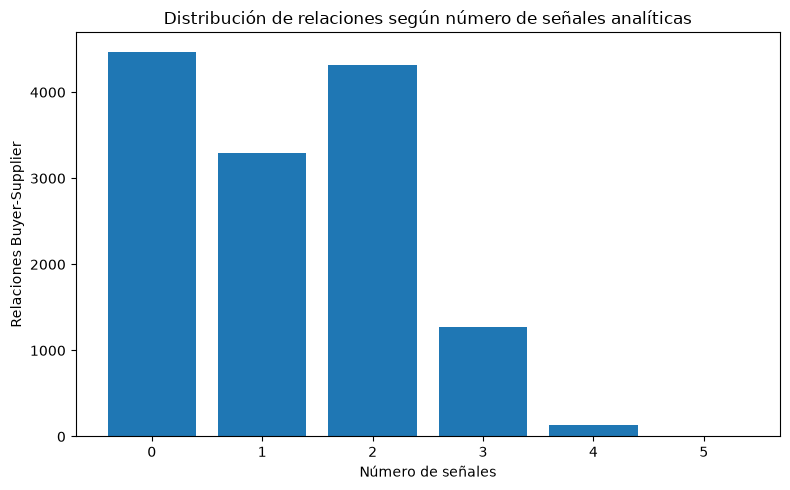

In [24]:
# Distribución del número de señales convergentes.

plot_df = signal_count_summary.copy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    plot_df["numero_senales"].astype(str),
    plot_df["relaciones"],
)
ax.set_title(
    "Distribución de relaciones según número de señales analíticas"
)
ax.set_xlabel("Número de señales")
ax.set_ylabel("Relaciones Buyer-Supplier")
plt.tight_layout()
plt.show()


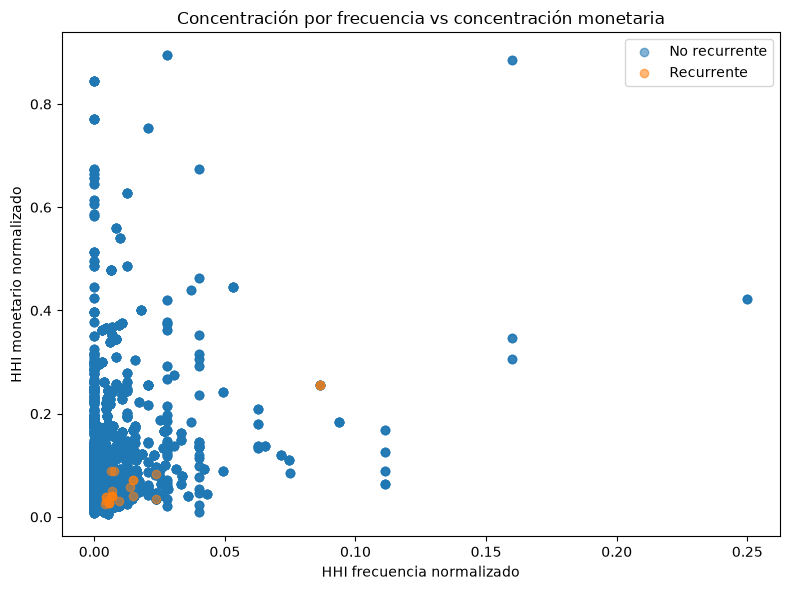

In [25]:
# HHI monetario vs frecuencia, resaltando recurrencia.

plot_hhi = ri[
    [
        "hhi_frecuencia_normalizado",
        "hhi_monetario_normalizado",
        "recurrence_any",
    ]
].dropna()

fig, ax = plt.subplots(figsize=(8, 6))

for recurrence_value, group in plot_hhi.groupby("recurrence_any"):
    ax.scatter(
        group["hhi_frecuencia_normalizado"],
        group["hhi_monetario_normalizado"],
        alpha=0.55,
        label=(
            "Recurrente"
            if recurrence_value == 1
            else "No recurrente"
        ),
    )

ax.set_title(
    "Concentración por frecuencia vs concentración monetaria"
)
ax.set_xlabel("HHI frecuencia normalizado")
ax.set_ylabel("HHI monetario normalizado")
ax.legend()
plt.tight_layout()
plt.show()


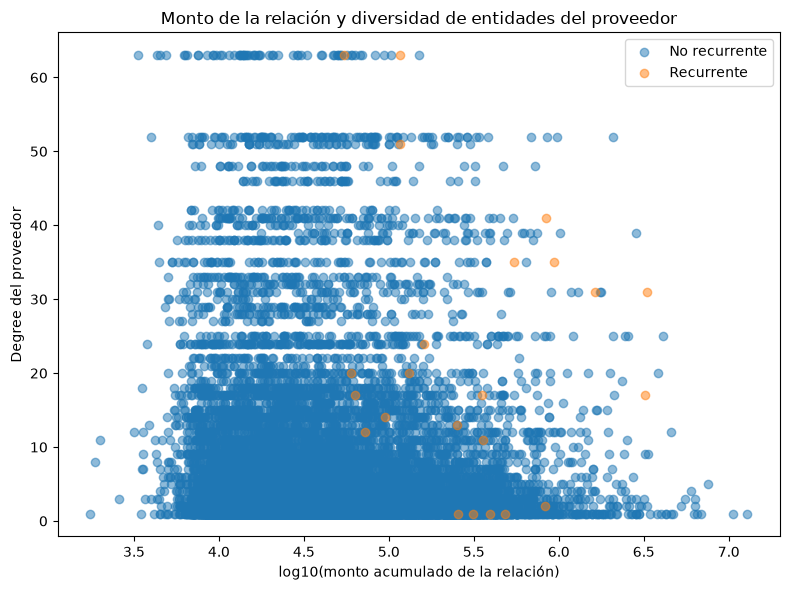

In [26]:
# Relación entre monto acumulado y centralidad estructural del proveedor.

plot_structural = ri[
    [
        "relation_amount",
        "supplier_degree",
        "recurrence_any",
    ]
].dropna()

plot_structural = plot_structural[
    plot_structural["relation_amount"] > 0
].copy()

fig, ax = plt.subplots(figsize=(8, 6))

for recurrence_value, group in plot_structural.groupby("recurrence_any"):
    ax.scatter(
        np.log10(group["relation_amount"]),
        group["supplier_degree"],
        alpha=0.5,
        label=(
            "Recurrente"
            if recurrence_value == 1
            else "No recurrente"
        ),
    )

ax.set_title(
    "Monto de la relación y diversidad de entidades del proveedor"
)
ax.set_xlabel("log10(monto acumulado de la relación)")
ax.set_ylabel("Degree del proveedor")
ax.legend()
plt.tight_layout()
plt.show()


In [27]:
# Selección de cinco relaciones con alta convergencia
# para construir casos exploratorios.
#
# La cobertura se usa como criterio de desempate después del número de señales,
# no como una señal adicional.

case_candidates_df = (
    ri.sort_values(
        [
            "signal_count",
            "n_signals_available",
            "recurrence_any",
            "relation_amount",
            "supplier_degree",
            "supplier_betweenness",
        ],
        ascending=[
            False,
            False,
            False,
            False,
            False,
            False,
        ],
    )
    .drop_duplicates(
        ["buyer_id", "supplier_id"]
    )
    .head(5)
    .copy()
)

case_cols = [
    "buyer_id",
    "buyer_name_network",
    "supplier_id",
    "supplier_name_network",
    "relation_frequency",
    "relation_amount",
    "max_procesos_90d",
    "recurrent_cpc5_count",
    "single_bidder_share",
    "participation_coverage",
    "hhi_monetario_normalizado",
    "hhi_frecuencia_normalizado",
    "supplier_degree",
    "supplier_strength_frequency",
    "supplier_strength_amount",
    "supplier_betweenness",
    "n_signals_available",
    "signal_count",
    "complete_signal_coverage",
]

display(
    case_candidates_df[
        [
            c
            for c in case_cols
            if c in case_candidates_df.columns
        ]
    ]
)

,buyer_id,buyer_name_network,supplier_id,supplier_name_network,relation_frequency,relation_amount,max_procesos_90d,recurrent_cpc5_count,single_bidder_share,participation_coverage,hhi_monetario_normalizado,hhi_frecuencia_normalizado,supplier_degree,supplier_strength_frequency,supplier_strength_amount,supplier_betweenness,n_signals_available,signal_count,complete_signal_coverage
10048,EC-RUC-1768046450001-54651,HOSPITAL DE ESPECIALIDADES CARLOS ANDRADE MARIN,EC-RUC-1790691810001-4033,SIMED S. A.,7,"3,293,607.460000",4,1,0.571429,1.000000,0.027744,0.005543,31,73,"15,550,452.120000","62,799.266997",6,5,True
4057,EC-RUC-0968560160001-2810,HOSPITAL DE ESPECIALIDADES - TEODORO MALDONADO...,EC-RUC-1790691810001-4033,SIMED S. A.,8,"1,628,605.710000",5,1,0.625000,1.000000,0.031681,0.009365,31,73,"15,550,452.120000","62,799.266997",6,5,True
13086,EC-RUC-2160000210001-3277,GOBIERNO AUTONOMO DESCENTRALIZADO DE LA PROVIN...,EC-RUC-1791814711001-19486,FATOSLA C.A.,1,"4,544,148.410000",1,0,1.000000,1.000000,0.352082,0.006639,12,14,"9,492,313.060000","151,928.540323",6,5,True
3538,EC-RUC-0960002000001-100696,Gobierno Municipal de Santa Lucia,EC-RUC-0992745762001-507503,MOTORES Y TRACTORES MOTRAC S.A.,1,"944,887.980000",1,0,1.000000,1.000000,0.298011,0.000000,10,11,"4,076,909.070000","53,178.130394",6,5,True
3212,EC-RUC-0860047630001-534517,DIRECCION DISTRITAL 08D01 - ESMERALDAS - EDUCA...,EC-RUC-0890044182001-177868,SERVICIOS MULTIPLES ESMERALDAS MULTIESMERALDAS...,2,"590,859.960000",2,0,1.000000,1.000000,0.674569,0.040000,4,5,"1,430,945.600000","20,041.693683",6,5,True


In [28]:
# Trazabilidad a procedimientos de los casos seleccionados

case_keys = case_candidates_df[
    ["buyer_id", "supplier_id"]
].drop_duplicates()

case_procedures_df = (
    adjudicaciones_df
    .merge(
        case_keys,
        on=["buyer_id", "supplier_id"],
        how="inner",
    )
    .merge(
        procedure_participation_df[
            ["ocid", "number_of_tenderers"]
        ],
        on="ocid",
        how="left",
    )
    .sort_values(
        ["buyer_id", "supplier_id", "award_date_dt"]
    )
)

case_procedure_cols = [
    "buyer_id",
    "supplier_id",
    "ocid",
    "award_date_local",
    "award_amount",
    "cpc_5",
    "number_of_tenderers",
]

display(
    case_procedures_df[
        [c for c in case_procedure_cols if c in case_procedures_df.columns]
    ].head(100)
)


,buyer_id,supplier_id,ocid,award_date_local,award_amount,cpc_5,number_of_tenderers
15,EC-RUC-0860047630001-534517,EC-RUC-0890044182001-177868,ocds-5wno2w-SIE-DIRECCIONDISTRITAL-08D01-E-EDU...,2025-05-27 13:09:06,"329,140.860000",64312,1.000000
16,EC-RUC-0860047630001-534517,EC-RUC-0890044182001-177868,ocds-5wno2w-SIE-DIRECCIONDISTRITAL-08D01-E-EDU...,2025-05-28 13:14:56,"261,719.100000",64312,1.000000
0,EC-RUC-0960002000001-100696,EC-RUC-0992745762001-507503,ocds-5wno2w-SIE-GADMCSL-2025-008-100696,2025-06-30 14:45:53,"944,887.980000",44421,1.000000
12,EC-RUC-0968560160001-2810,EC-RUC-1790691810001-4033,ocds-5wno2w-SIE-HTMC-2025-053-2810,2025-11-07 17:04:00,"215,000.000000",35290,3.000000
10,EC-RUC-0968560160001-2810,EC-RUC-1790691810001-4033,ocds-5wno2w-SIE-HTMC-2025-055-2810,2025-11-21 16:44:34,"245,052.660000",35290,3.000000
1,EC-RUC-0968560160001-2810,EC-RUC-1790691810001-4033,ocds-5wno2w-SIE-HTMC-2025-069-2810,2025-12-05 12:59:50,"97,443.590000",35290,1.000000
9,EC-RUC-0968560160001-2810,EC-RUC-1790691810001-4033,ocds-5wno2w-SIE-HTMC-2025-056-2810,2025-12-08 11:19:11,"166,719.830000",35290,1.000000
2,EC-RUC-0968560160001-2810,EC-RUC-1790691810001-4033,ocds-5wno2w-SIE-HTMC-2025-063-2810,2025-12-31 14:53:50,"236,716.830000",35290,1.000000
7,EC-RUC-0968560160001-2810,EC-RUC-1790691810001-4033,ocds-5wno2w-SIE-HTMC-2025-091-2810,2026-02-18 15:26:19,"178,000.000000",35290,2.000000
3,EC-RUC-0968560160001-2810,EC-RUC-1790691810001-4033,ocds-5wno2w-SIE-HTMC-2025-070-2810,2026-03-05 09:34:57,"381,567.140000",35290,1.000000


In [29]:
# Exportar resultados.

exports = {
    "01_concentracion_entidades_2025.csv": concentration_df,
    "02_recurrencia_buyer_supplier_cpc5_2025.csv": recurrence_df,
    "03_relaciones_integradas_2025.csv": ri,
    "04_resumen_cruces_2025.csv": cross_summary_df,
    "05_resumen_patrones_2025.csv": pattern_summary_df,
    "06_sensibilidad_concentracion_2025.csv": concentration_sensitivity_df,
    "07_sensibilidad_recurrencia_2025.csv": recurrence_sensitivity_df,
    "08_casos_priorizados_exploratorios_2025.csv": case_candidates_df,
    "09_procedimientos_casos_2025.csv": case_procedures_df,
    "10_umbrales_exploratorios_2025.csv": screening_thresholds_df,
    "11_umbrales_usados_2025.csv": thresholds_used_df,
    "12_cobertura_senales_2025.csv": coverage_summary_df,
    "13_sensibilidad_single_bidder_2025.csv": single_bidder_sensitivity_df,
    "14_single_bidder_por_frecuencia_2025.csv": single_bidder_frequency_df,
    "15_embudo_priorizacion_2025.csv": prioritization_funnel_df,
}

for filename, df in exports.items():
    path = ANALYTICS_DIR / filename

    df.to_csv(
        path,
        index=False,
        encoding="utf-8-sig",
    )

    print(
        f"{filename}: {len(df):,} filas"
    )

01_concentracion_entidades_2025.csv: 687 filas
02_recurrencia_buyer_supplier_cpc5_2025.csv: 14,400 filas
03_relaciones_integradas_2025.csv: 13,493 filas
04_resumen_cruces_2025.csv: 6 filas
05_resumen_patrones_2025.csv: 6 filas
06_sensibilidad_concentracion_2025.csv: 4 filas
07_sensibilidad_recurrencia_2025.csv: 12 filas
08_casos_priorizados_exploratorios_2025.csv: 5 filas
09_procedimientos_casos_2025.csv: 19 filas
10_umbrales_exploratorios_2025.csv: 12 filas
11_umbrales_usados_2025.csv: 7 filas
12_cobertura_senales_2025.csv: 7 filas
13_sensibilidad_single_bidder_2025.csv: 3 filas
14_single_bidder_por_frecuencia_2025.csv: 3 filas
15_embudo_priorizacion_2025.csv: 7 filas
